# Dublin Bus Passenger Flow: Seasonal Inspection

This notebook performs a focused inspection of the supplied weekly passenger-journey series and tests whether its pattern changes systematically through the year.

**What it covers**
- data-quality checks and a transparent cleaning step;
- the long-run weekly series, including the COVID-19 disruption;
- yearly passenger-flow levels;
- a recent, trend-adjusted seasonal profile based on complete 2023-2025 years; and
- a compact seasonal conclusion.

**Important scope note:** the source file labels the series as *"Bus, excluding Dublin Metro"*. This notebook therefore describes it as the supplied bus passenger-journey series. It does not infer a more specific operator definition than the file provides.

To rerun after downloading, place `THA25.20260622T100651.csv` beside this notebook. The loading cell also recognises the original workspace location.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter

# A calm, high-contrast palette for readable research figures.
NAVY = "#16324F"
GREEN = "#2E8B57"
TEAL = "#1F7A8C"
GOLD = "#D98E04"
CORAL = "#C65146"
LIGHT_GREY = "#E9EEF2"
MID_GREY = "#6B7785"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#D9E1E8",
    "grid.linewidth": 0.7,
})

def million_formatter(value, _):
    return f"{value / 1_000_000:.1f}M"

## 1. Load and inspect the source data

In [2]:
INPUT_CANDIDATES = [
    Path("../data/raw/THA25.20260622T100651.csv"),
    Path("../data/raw/THA25.20260622T100651.csv"),
]
DATA_FILE = next((path for path in INPUT_CANDIDATES if path.exists()), None)

if DATA_FILE is None:
    raise FileNotFoundError(
        "Could not find THA25.20260622T100651.csv. "
        "Place it beside this notebook or update INPUT_CANDIDATES."
    )

raw = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
print(f"Loaded: {DATA_FILE}")
print(f"Rows: {len(raw):,} | Columns: {len(raw.columns)}")
raw.head()

Loaded: ..\data\raw\THA25.20260622T100651.csv
Rows: 389 | Columns: 5


,Statistic Label,Week,Mode of Transport,UNIT,VALUE
0,Passenger Journeys,2019 Week 01,"Bus, excluding Dublin Metro",Number,497598.0
1,Passenger Journeys,2019 Week 02,"Bus, excluding Dublin Metro",Number,633764.0
2,Passenger Journeys,2019 Week 03,"Bus, excluding Dublin Metro",Number,678097.0
3,Passenger Journeys,2019 Week 04,"Bus, excluding Dublin Metro",Number,676140.0
4,Passenger Journeys,2019 Week 05,"Bus, excluding Dublin Metro",Number,672440.0


In [3]:
# Extract year/week case-insensitively. This also fixes the source label "2024 week 44".
extracted = raw["Week"].astype(str).str.extract(
    r"(?i)^(?P<year>\d{4})\s+week\s+(?P<week>\d{1,2})$"
)

data = raw.copy()
data["year"] = pd.to_numeric(extracted["year"], errors="coerce")
data["week_number"] = pd.to_numeric(extracted["week"], errors="coerce")
data["passenger_journeys"] = pd.to_numeric(data["VALUE"], errors="coerce")

invalid_week_labels = data["year"].isna().sum()
duplicate_weeks = data.duplicated(["year", "week_number"], keep=False).sum()
missing_values = data["passenger_journeys"].isna().sum()

quality_summary = pd.DataFrame({
    "Check": ["Source rows", "Unparseable week labels", "Duplicate year-week records", "Missing journey values"],
    "Result": [len(data), invalid_week_labels, duplicate_weeks, missing_values],
    "Treatment": [
        "All rows retained.",
        "No row dropped solely for label case; matching is case-insensitive.",
        "None expected; investigate if non-zero.",
        "Kept as missing; not interpolated for this descriptive inspection.",
    ],
})
display(quality_summary)

# Week 53 is retained where present, but is not used in the 52-week seasonal comparison.
data = data.dropna(subset=["year", "week_number"]).copy()
data[["year", "week_number"]] = data[["year", "week_number"]].astype(int)
data["week_start"] = pd.to_datetime(
    data["year"].astype(str) + "-W" + data["week_number"].astype(str).str.zfill(2) + "-1",
    format="%G-W%V-%u",
    errors="coerce",
)
data = data.sort_values(["year", "week_number"]).reset_index(drop=True)

,Check,Result,Treatment
0,Source rows,389,All rows retained.
1,Unparseable week labels,0,No row dropped solely for label case; matching...
2,Duplicate year-week records,0,None expected; investigate if non-zero.
3,Missing journey values,3,Kept as missing; not interpolated for this des...


In [4]:
annual_coverage = (
    data.groupby("year", as_index=False)
    .agg(
        recorded_weeks=("week_number", "size"),
        first_week=("week_number", "min"),
        last_week=("week_number", "max"),
        missing_values=("passenger_journeys", lambda values: values.isna().sum()),
        mean_weekly_journeys=("passenger_journeys", "mean"),
    )
)
annual_coverage["mean_weekly_journeys"] = annual_coverage["mean_weekly_journeys"].round().astype("Int64")
display(annual_coverage)

,year,recorded_weeks,first_week,last_week,missing_values,mean_weekly_journeys
0,2019,53,1,53,1,709648
1,2020,53,1,53,0,368048
2,2021,53,1,53,1,404644
3,2022,53,1,53,1,680676
4,2023,52,1,52,0,839327
5,2024,52,1,52,0,928388
6,2025,52,1,52,0,963431
7,2026,21,1,21,0,1013373


## 2. Long-run pattern

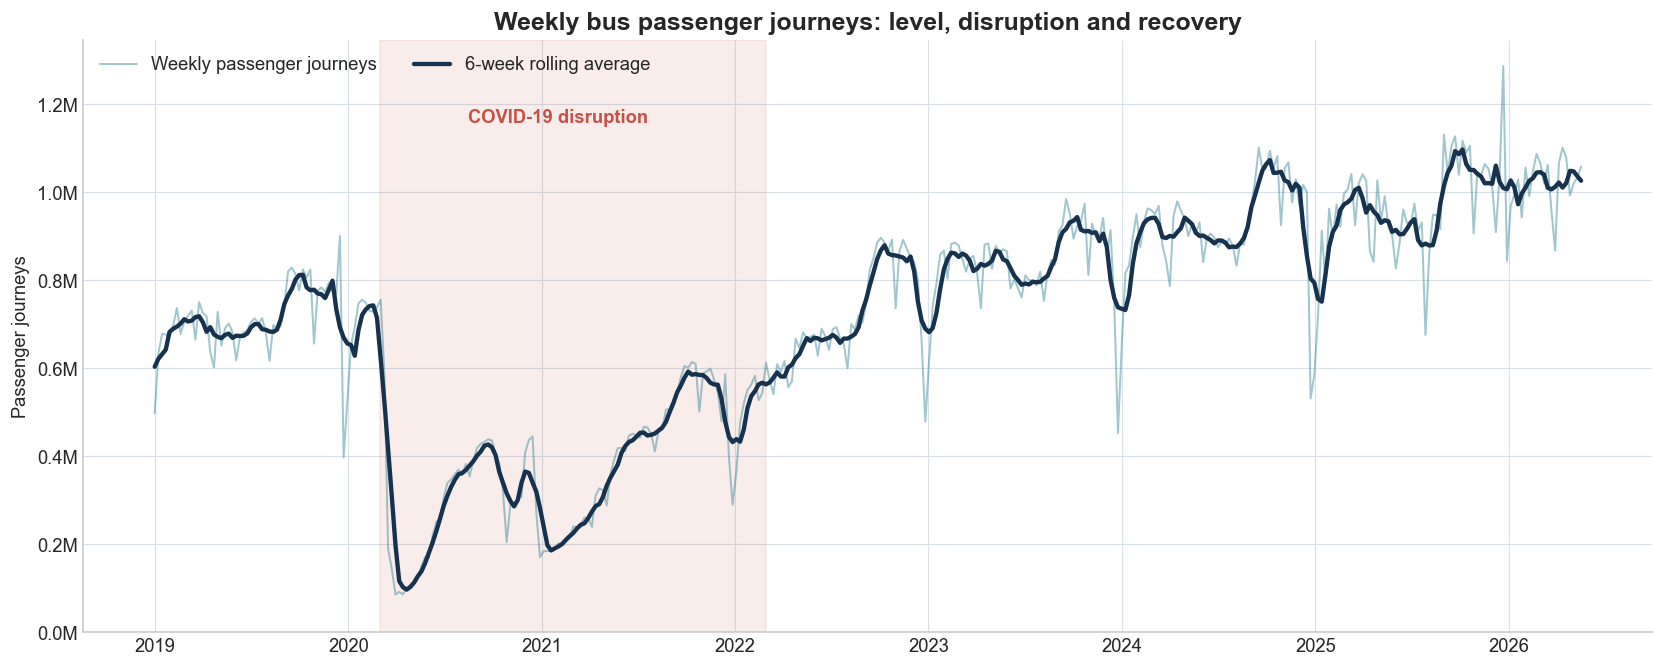

In [5]:
plot_data = data.dropna(subset=["passenger_journeys"]).copy()
plot_data["rolling_6_week"] = plot_data["passenger_journeys"].rolling(6, center=True, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(14, 5.7))
ax.plot(
    plot_data["week_start"], plot_data["passenger_journeys"],
    color=TEAL, linewidth=1.2, alpha=0.42, label="Weekly passenger journeys"
)
ax.plot(
    plot_data["week_start"], plot_data["rolling_6_week"],
    color=NAVY, linewidth=2.6, label="6-week rolling average"
)

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2022-02-28"), color=CORAL, alpha=0.10)
ax.text(pd.Timestamp("2021-02-01"), 1_170_000, "COVID-19 disruption", color=CORAL,
        ha="center", va="center", fontweight="bold")

ax.set_title("Weekly bus passenger journeys: level, disruption and recovery")
ax.set_ylabel("Passenger journeys")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(FuncFormatter(million_formatter))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

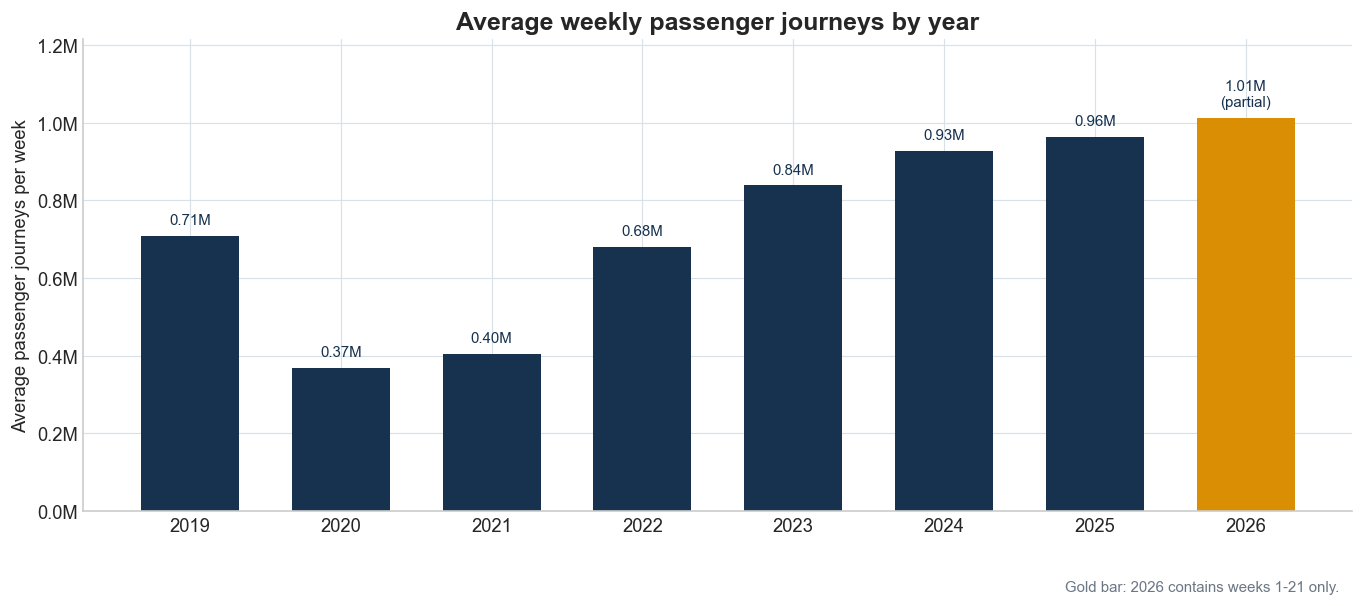

In [6]:
annual = (
    plot_data.groupby("year", as_index=False)
    .agg(mean_weekly_journeys=("passenger_journeys", "mean"), observed_weeks=("week_number", "count"))
)
annual["is_partial_year"] = annual["observed_weeks"] < 50

fig, ax = plt.subplots(figsize=(11.5, 5.2))
colors = [GOLD if partial else NAVY for partial in annual["is_partial_year"]]
bars = ax.bar(annual["year"].astype(str), annual["mean_weekly_journeys"], color=colors, width=0.65)

for bar, row in zip(bars, annual.itertuples()):
    label = f"{row.mean_weekly_journeys / 1_000_000:.2f}M"
    if row.is_partial_year:
        label += "\n(partial)"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 22_000, label,
            ha="center", va="bottom", fontsize=9, color=NAVY)

ax.set_title("Average weekly passenger journeys by year")
ax.set_ylabel("Average passenger journeys per week")
ax.yaxis.set_major_formatter(FuncFormatter(million_formatter))
ax.set_ylim(0, annual["mean_weekly_journeys"].max() * 1.20)
ax.text(0.99, -0.17, "Gold bar: 2026 contains weeks 1-21 only.", transform=ax.transAxes,
        ha="right", color=MID_GREY, fontsize=9)
plt.tight_layout()
plt.show()

## 3. Seasonal pattern

A long-term increase in passenger journeys can mask a recurring within-year pattern. To isolate seasonality, each week's value is divided by its own year's mean weekly value and expressed as an index where **100 = that year's average week**.

The core seasonal baseline uses the complete post-recovery years **2023-2025**. The partial 2026 year is shown for context but not included in the baseline.

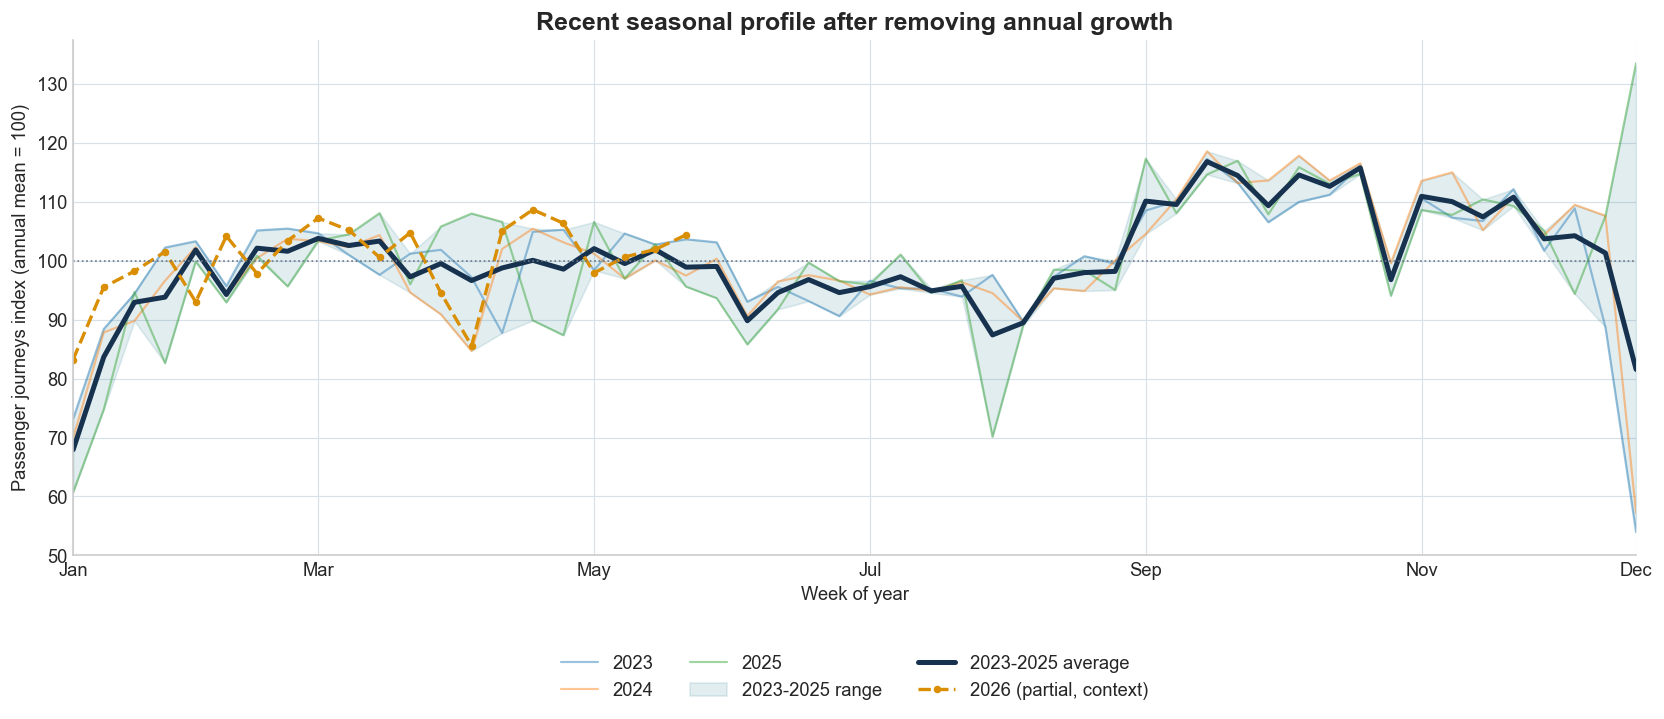

In [7]:
# Use weeks 1-52 for comparable calendar-year profiles.
seasonal_data = data.query("week_number <= 52").dropna(subset=["passenger_journeys"]).copy()
seasonal_data["annual_mean"] = seasonal_data.groupby("year")["passenger_journeys"].transform("mean")
seasonal_data["seasonal_index"] = 100 * seasonal_data["passenger_journeys"] / seasonal_data["annual_mean"]

baseline_years = [2023, 2024, 2025]
baseline = seasonal_data[seasonal_data["year"].isin(baseline_years)].copy()
profile = (
    baseline.groupby("week_number", as_index=False)
    .agg(
        mean_index=("seasonal_index", "mean"),
        low_index=("seasonal_index", "min"),
        high_index=("seasonal_index", "max"),
        standard_deviation=("seasonal_index", "std"),
    )
)

fig, ax = plt.subplots(figsize=(14, 6.2))
for year, group in baseline.groupby("year"):
    ax.plot(group["week_number"], group["seasonal_index"], linewidth=1.3,
            alpha=0.45, label=str(year))

ax.fill_between(profile["week_number"], profile["low_index"], profile["high_index"],
                color=TEAL, alpha=0.13, label="2023-2025 range")
ax.plot(profile["week_number"], profile["mean_index"], color=NAVY, linewidth=3.0,
        label="2023-2025 average")

context_2026 = seasonal_data[seasonal_data["year"].eq(2026)]
ax.plot(context_2026["week_number"], context_2026["seasonal_index"], color=GOLD,
        linewidth=2.0, linestyle="--", marker="o", markersize=3.5, label="2026 (partial, context)")

ax.axhline(100, color=MID_GREY, linewidth=1, linestyle=":")
ax.set_title("Recent seasonal profile after removing annual growth")
ax.set_xlabel("Week of year")
ax.set_ylabel("Passenger journeys index (annual mean = 100)")
ax.set_xlim(1, 52)
ax.set_xticks([1, 9, 18, 27, 36, 45, 52])
ax.set_xticklabels(["Jan", "Mar", "May", "Jul", "Sep", "Nov", "Dec"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
plt.tight_layout()
plt.show()

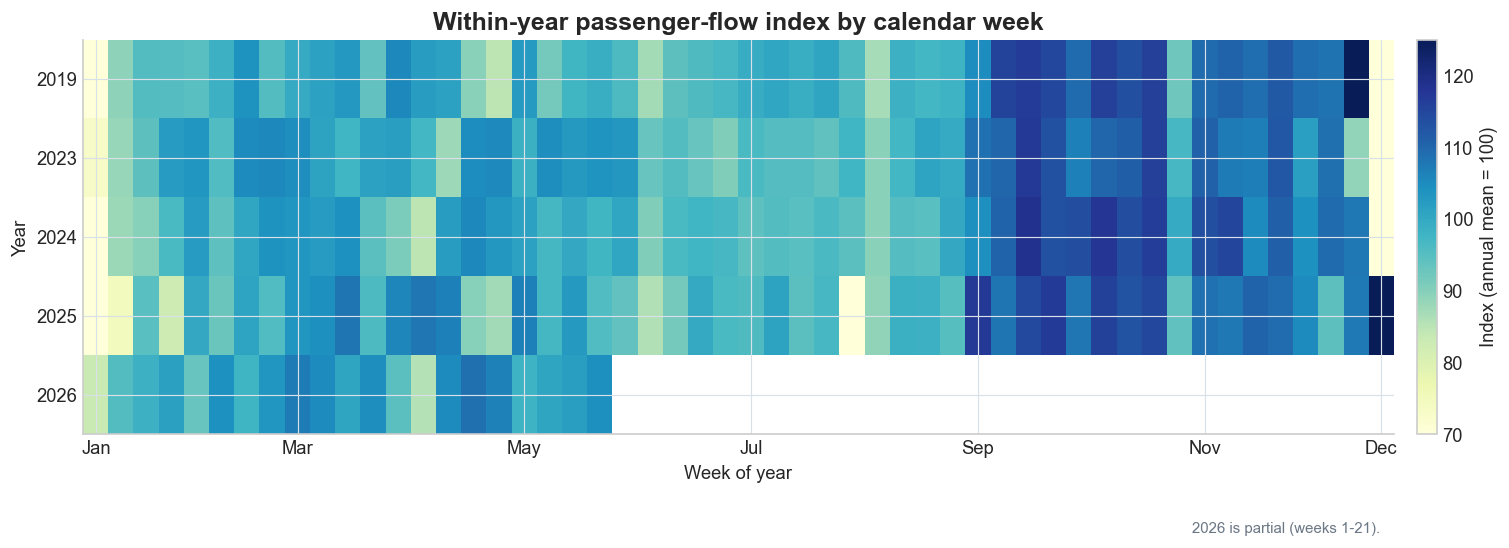

In [8]:
heatmap_years = [2019, 2023, 2024, 2025, 2026]
heatmap_data = (
    seasonal_data[seasonal_data["year"].isin(heatmap_years)]
    .pivot(index="year", columns="week_number", values="seasonal_index")
    .reindex(index=heatmap_years, columns=range(1, 53))
)

fig, ax = plt.subplots(figsize=(14, 4.8))
image = ax.imshow(heatmap_data, aspect="auto", cmap="YlGnBu", vmin=70, vmax=125)
ax.set_title("Within-year passenger-flow index by calendar week")
ax.set_xlabel("Week of year")
ax.set_ylabel("Year")
ax.set_yticks(range(len(heatmap_years)))
ax.set_yticklabels(heatmap_years)
ax.set_xticks([0, 8, 17, 26, 35, 44, 51])
ax.set_xticklabels(["Jan", "Mar", "May", "Jul", "Sep", "Nov", "Dec"])
colorbar = fig.colorbar(image, ax=ax, pad=0.015)
colorbar.set_label("Index (annual mean = 100)")
ax.text(0.99, -0.25, "2026 is partial (weeks 1-21).", transform=ax.transAxes,
        ha="right", color=MID_GREY, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Compact findings

In [9]:
period_map = {
    "Jan-Feb": range(1, 9),
    "Mar-May": range(9, 23),
    "Jun-Aug": range(23, 36),
    "Sep-Nov": range(36, 49),
    "Dec": range(49, 53),
}
period_summary = pd.DataFrame({
    "Period": list(period_map),
    "Average seasonal index": [
        profile.set_index("week_number").loc[list(weeks), "mean_index"].mean()
        for weeks in period_map.values()
    ],
})
period_summary["Average seasonal index"] = period_summary["Average seasonal index"].round(1)
display(period_summary)

lowest = profile.nsmallest(3, "mean_index")
highest = profile.nlargest(3, "mean_index")
summer_index = period_summary.loc[period_summary["Period"].eq("Jun-Aug"), "Average seasonal index"].iat[0]
autumn_index = period_summary.loc[period_summary["Period"].eq("Sep-Nov"), "Average seasonal index"].iat[0]

print("Seasonal interpretation (based on complete 2023-2025 years):")
print(f"- There is a clear seasonal pattern after annual growth is removed.")
print(f"- Sep-Nov is the strongest broad period ({autumn_index:.1f}), about {(autumn_index / summer_index - 1) * 100:.0f}% above Jun-Aug ({summer_index:.1f}).")
print(f"- The lowest average weeks are {', '.join('W' + str(int(w)) for w in lowest['week_number'])}; the highest are {', '.join('W' + str(int(w)) for w in highest['week_number'])}.")
print("- Interpret individual holiday-adjacent weeks cautiously: their timing and the calendar definition can vary by year.")

,Period,Average seasonal index
0,Jan-Feb,92.3
1,Mar-May,100.1
2,Jun-Aug,94.6
3,Sep-Nov,110.7
4,Dec,97.7


Seasonal interpretation (based on complete 2023-2025 years):
- There is a clear seasonal pattern after annual growth is removed.
- Sep-Nov is the strongest broad period (110.7), about 17% above Jun-Aug (94.6).
- The lowest average weeks are W1, W52, W2; the highest are W38, W43, W41.
- Interpret individual holiday-adjacent weeks cautiously: their timing and the calendar definition can vary by year.


## Conclusion

The supplied weekly series shows meaningful **seasonal fluctuation**, not just long-term growth. In the recent complete years, passenger flow is typically lowest around the start of January and during parts of the summer, then rises to a sustained high during September-November. The 2020-2022 period is visibly dominated by disruption and recovery, so it should not be used as the principal basis for ordinary seasonal planning.

For later modelling work, use a recent multi-year seasonal factor by calendar week, retain an explicit holiday/calendar feature where possible, and keep the pandemic years separate from baseline demand estimation.